In [39]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

In [2]:
os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones")

In [3]:
# Recordemos la pregunta a responder: “¿Determinados tipos de victimización o delitos generan cambios concretos en las conductas cotidianas de las personas?”

In [4]:
### Encuesta México Victimización 2024

In [5]:
TMod_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TMod_Vic_2024_limpio.csv")

In [6]:
TPer_Vic1_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TPer_Vic1_2024_limpio.csv")

In [7]:
TPer_Vic2_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TPer_Vic2_2024_limpio.csv")

In [8]:
TSDem_2024 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TSDem_2024_limpio.csv")

In [9]:
### Encuesta México Victimización 2025

In [10]:
TMod_2025 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TMod_Vic_2025_limpio.csv")

In [11]:
TPer_Vic1_2025 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TPer_Vic1_2025_limpio.csv")

In [12]:
TPer_Vic2_2025 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TPer_Vic2_2025_limpio.csv")

In [13]:
TSDem_2025 = pd.read_csv(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\Poster correciones\datos_limpios\TSDem_2025_limpio.csv")

In [14]:
# Vamos a quedarnos solo con las variables con las que trabajamos en la parte no supervisada

In [15]:
# ============================================================
# Variables a conservar (diccionario del PDF, pág. 8 en adelante)
# ============================================================

# --- TMod: detalle del delito (sección BP1) ---
vars_TMod = [
    'BP1_4',    # Hora
    'BP1_5',    # Lugar
    'BP1_9',    # Nº delincuentes
    'BP1_15',   # Portó arma
    'BP1_16_1', # Arma de fuego
    'BP1_16_2', # Arma blanca
    'BP1_16_3', # Objeto contundente
    'BP1_16_4', # Otra arma
    'BP1_16_9', # Arma NS/NR
    'BP1_17',   # Lesión con arma
    'BP1_18',   # Otra violencia física
    'BP1_33',   # Daño principal
]

# --- TPer_Vic1: percepción de inseguridad y miedo conductual (AP4) ---
vars_TPer_Vic1 = [
    # Percepción de inseguridad geográfica
    'AP4_3_1',   # colonia / localidad
    'AP4_3_2',   # municipio
    # Percepción de seguridad en espacios específicos
    'AP4_4_01',  # casa
    'AP4_4_03',  # calle
    'AP4_4_05',  # mercado
    'AP4_4_06',  # centro comercial
    'AP4_4_07',  # banco
    'AP4_4_08',  # cajero automático
    'AP4_4_09',  # transporte público
    'AP4_4_12',  # parque / centro recreativo
    'AP4_4_A',   # caminar solo/a de noche
    # Cambios de hábitos por miedo (variable dependiente)
    'AP4_10_01', # dejó de salir de noche
    'AP4_10_02', # dejó de dejar salir a menores
    'AP4_10_03', # dejó de visitar parientes/amigos
    'AP4_10_04', # dejó de usar joyas
    'AP4_10_05', # dejó de llevar efectivo
    'AP4_10_06', # dejó de usar tarjeta
    'AP4_10_08', # dejó de usar transporte público
    'AP4_10_09', # dejó de ir al cine/teatro
    'AP4_10_10', # dejó de salir a caminar
    'AP4_10_11', # dejó de comer/cenar fuera
    'AP4_10_12', # dejó de ir al estadio
    'AP4_10_14', # dejó de viajar por carretera
    'AP4_10_15', # dejó de llevar celular
]

# --- TPer_Vic2: victimización personal y en el hogar (AP6 / AP7) ---
vars_TPer_Vic2 = [
    # Secuestro en el hogar
    'AP6_9',     # secuestro hogar (antes del año de ref.)
    'AP6_10_1',  # secuestro hogar (durante el año de ref.)
    # Filtro: ¿sufrió el delito? (AP7_3_*)
    'AP7_3_07',  # fraude bancario
    'AP7_3_08',  # fraude al consumidor
    'AP7_3_09',  # extorsión
    'AP7_3_12',  # secuestro personal
    'AP7_3_13',  # hostigamiento/intimidación sexual
    # Cantidad de veces (AP7_4_*)
    'AP7_4_07',  # fraude bancario
    'AP7_4_08',  # fraude al consumidor
    'AP7_4_09',  # extorsión
    'AP7_4_12',  # secuestro personal
]

In [16]:
# ============================================================
# Columnas llave / de diseño que conviene NO perder para luego
# poder mergear las tablas. Se conservan solo si existen.
# ============================================================
posibles_ids = [
    # llaves de unidad
    'ID_PER', 'ID_VIV', 'ID_HOG', 'ID_PERSONA',
    'UPM', 'UPM_DIS', 'VIV_SEL', 'HOGAR', 'N_REN', 'N_HOG',
    'CVE_ENT', 'CVE_MUN', 'ENT', 'MUN',
    # llaves del módulo (nivel delito)
    'BPCOD', 'ND_TIPO', 'TD_TIPO', 'NDELITO', 'N_DELITO',
    # factores de expansión / diseño muestral
    'FAC_ELE', 'FAC_HOG', 'FAC_VIV', 'EST_DIS',
]

In [17]:
def filtrar(df, variables, nombre):
    presentes = [c for c in variables   if c in df.columns]
    faltantes = [c for c in variables   if c not in df.columns]
    ids       = [c for c in posibles_ids if c in df.columns]
    cols      = ids + presentes
    print(f"--- {nombre} ---")
    print(f"  IDs conservados ({len(ids)}): {ids}")
    print(f"  Variables conservadas: {len(presentes)}/{len(variables)}")
    if faltantes:
        print(f"  ⚠ No encontradas: {faltantes}")
    print(f"  Shape resultante: {df[cols].shape}\n")
    return df[cols].copy()

# 2024
TMod_2024_sel      = filtrar(TMod_2024,      vars_TMod,      "TMod 2024")
TPer_Vic1_2024_sel = filtrar(TPer_Vic1_2024, vars_TPer_Vic1, "TPer_Vic1 2024")
TPer_Vic2_2024_sel = filtrar(TPer_Vic2_2024, vars_TPer_Vic2, "TPer_Vic2 2024")

# 2025
TMod_2025_sel      = filtrar(TMod_2025,      vars_TMod,      "TMod 2025")
TPer_Vic1_2025_sel = filtrar(TPer_Vic1_2025, vars_TPer_Vic1, "TPer_Vic1 2025")
TPer_Vic2_2025_sel = filtrar(TPer_Vic2_2025, vars_TPer_Vic2, "TPer_Vic2 2025")

--- TMod 2024 ---
  IDs conservados (11): ['ID_PER', 'ID_VIV', 'ID_HOG', 'UPM', 'UPM_DIS', 'VIV_SEL', 'HOGAR', 'BPCOD', 'ND_TIPO', 'TD_TIPO', 'EST_DIS']
  Variables conservadas: 12/12
  Shape resultante: (37614, 23)

--- TPer_Vic1 2024 ---
  IDs conservados (12): ['ID_PER', 'ID_VIV', 'ID_HOG', 'UPM', 'UPM_DIS', 'VIV_SEL', 'HOGAR', 'CVE_ENT', 'CVE_MUN', 'FAC_ELE', 'FAC_HOG', 'EST_DIS']
  Variables conservadas: 24/24
  Shape resultante: (89630, 36)

--- TPer_Vic2 2024 ---
  IDs conservados (12): ['ID_PER', 'ID_VIV', 'ID_HOG', 'UPM', 'UPM_DIS', 'VIV_SEL', 'HOGAR', 'CVE_ENT', 'CVE_MUN', 'FAC_ELE', 'FAC_HOG', 'EST_DIS']
  Variables conservadas: 11/11
  Shape resultante: (89630, 23)

--- TMod 2025 ---
  IDs conservados (11): ['ID_PER', 'ID_VIV', 'ID_HOG', 'UPM', 'UPM_DIS', 'VIV_SEL', 'HOGAR', 'BPCOD', 'ND_TIPO', 'TD_TIPO', 'EST_DIS']
  Variables conservadas: 12/12
  Shape resultante: (40280, 23)

--- TPer_Vic1 2025 ---
  IDs conservados (12): ['ID_PER', 'ID_VIV', 'ID_HOG', 'UPM', 'UPM_DIS', 

In [18]:
# Empezamos con reconocer cuales van a ser nuestras variables pertenecientes a Y o X:

In [19]:
items_Y = ['AP4_10_01','AP4_10_02','AP4_10_03','AP4_10_04','AP4_10_05',
           'AP4_10_06','AP4_10_08','AP4_10_09','AP4_10_10','AP4_10_11',
           'AP4_10_12','AP4_10_14','AP4_10_15']

for año, df in [('2024', TPer_Vic1_2024_sel), ('2025', TPer_Vic1_2025_sel)]:
    todos_nan = df[items_Y].isna().all(axis=1)
    print(año, '— filas con TODOS los AP4_10 en NaN:',
          todos_nan.sum(), f'({todos_nan.mean()*100:.2f}%)')

2024 — filas con TODOS los AP4_10 en NaN: 361 (0.40%)
2025 — filas con TODOS los AP4_10 en NaN: 258 (0.28%)


In [20]:
# ---- Llave de persona (según tu notebook) ----
ids_base = ["UPM", "VIV_SEL", "HOGAR", "R_SEL"]

# ---- Items que construyen la Y (cambio de conducta) ----
items_Y = ['AP4_10_01','AP4_10_02','AP4_10_03','AP4_10_04','AP4_10_05',
           'AP4_10_06','AP4_10_08','AP4_10_09','AP4_10_10','AP4_10_11',
           'AP4_10_12','AP4_10_14','AP4_10_15']

# ---- Variables de victimización que forman la X (Modelo 1) ----
items_X = ['AP7_3_05','AP7_3_06','AP7_3_07','AP7_3_08',
           'AP7_3_09','AP7_3_10','AP7_3_11','AP7_3_13',
           'AP6_9','AP6_10_1']

def a_num(s):
    """Coerce a numérico tratando 'b', blancos y booleanos como corresponde."""
    s = s.replace({True:1, False:0, 'True':1,'False':0,'TRUE':1,'FALSE':0,
                   'b':np.nan,'B':np.nan,'':np.nan,' ':np.nan,
                   'nan':np.nan,'NaN':np.nan,'None':np.nan, None:np.nan})
    return pd.to_numeric(s, errors='coerce')

def recode_binaria(s):
    """1=Sí ->1 ; 2=No ->0 ; ya-limpio 0 ->0 ; 9/blanco/NaN -> NaN."""
    return a_num(s).map({0:0, 1:1, 2:0}).astype('float')

def normaliza_cols(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip().str.upper()
    return df

In [21]:
def elegir_llave(per1, per2):
    if 'ID_PER' in per1.columns and 'ID_PER' in per2.columns:
        return ['ID_PER']
    return [c for c in ids_base if c in per1.columns and c in per2.columns]

def construir_base(per1, per2):
    per1, per2 = normaliza_cols(per1), normaliza_cols(per2)
    llave = elegir_llave(per1, per2)

    # ----- Y desde TPer_Vic1 -----
    items_Y_pres = [c for c in items_Y if c in per1.columns]
    Ymat   = per1[items_Y_pres].apply(a_num)
    cambio = (Ymat == 1)                       # True solo donde respondió "Sí"
    n_cambios   = cambio.sum(axis=1)
    todos_nan   = Ymat.isna().all(axis=1)      # las filas 0,3–0,4% que vimos
    Y = (n_cambios >= 1).astype('float')
    Y = Y.mask(todos_nan, np.nan)              # esas filas -> NaN (se excluyen)

    base_Y = per1[llave].copy()
    base_Y['Y_cambio_conducta'] = Y
    base_Y['n_cambios']         = n_cambios

    # ----- X desde TPer_Vic2 -----
    items_X_pres = [c for c in items_X if c in per2.columns]
    base_X = per2[llave].copy()
    cols_X = []
    for c in items_X_pres:
        base_X[c + '_bin'] = recode_binaria(per2[c])
        cols_X.append(c + '_bin')

    # ----- Merge 1:1 a nivel persona -----
    print("Duplicados de llave  per1:", per1.duplicated(llave).sum(),
          "| per2:", per2.duplicated(llave).sum())
    base = base_Y.merge(base_X, on=llave, how='inner')
    print(f"Merge: per1={len(per1)}  per2={len(per2)}  ->  base={len(base)}")
    return base, llave, cols_X

base_2024, llave_24, cols_X = construir_base(TPer_Vic1_2024, TPer_Vic2_2024)
base_2025, llave_25, _      = construir_base(TPer_Vic1_2025, TPer_Vic2_2025)

# Pooled (para los modelos con CV); guardamos el año por si querés controlarlo
base_2024['anio'] = 2024
base_2025['anio'] = 2025
base_pool = pd.concat([base_2024, base_2025], ignore_index=True)

Duplicados de llave  per1: 0 | per2: 0
Merge: per1=89630  per2=89630  ->  base=89630
Duplicados de llave  per1: 0 | per2: 0
Merge: per1=91182  per2=91182  ->  base=91182


In [22]:
def matriz_modelo(base, cols_X, nombre):
    # Quitamos filas sin Y (todos los AP4_10 en NaN) y casos incompletos en X
    n0 = len(base)
    base = base.dropna(subset=['Y_cambio_conducta'])
    base = base.dropna(subset=cols_X)
    X = base[cols_X].astype(int)
    y = base['Y_cambio_conducta'].astype(int)

    print(f"\n=== {nombre} ===")
    print(f"Filas: {n0} -> {len(base)} (se descartaron {n0-len(base)})")
    print("Tasa base de Y (cambió al menos una conducta):")
    print(y.value_counts(normalize=True).round(3).to_string())
    print("Prevalencia de cada predictor X:")
    print(X.mean().sort_values(ascending=False).round(4).to_string())
    return X, y

X_2024, y_2024 = matriz_modelo(base_2024, cols_X, "2024")
X_2025, y_2025 = matriz_modelo(base_2025, cols_X, "2025")
X_pool, y_pool = matriz_modelo(base_pool, cols_X, "Pooled 2024+2025")


=== 2024 ===
Filas: 89630 -> 88569 (se descartaron 1061)
Tasa base de Y (cambió al menos una conducta):
Y_cambio_conducta
1    0.687
0    0.313
Prevalencia de cada predictor X:
AP7_3_09_bin    0.0393
AP7_3_05_bin    0.0359
AP7_3_07_bin    0.0289
AP7_3_08_bin    0.0263
AP7_3_10_bin    0.0252
AP7_3_06_bin    0.0158
AP6_9_bin       0.0128
AP7_3_11_bin    0.0114
AP7_3_13_bin    0.0111
AP6_10_1_bin    0.0020

=== 2025 ===
Filas: 91182 -> 90743 (se descartaron 439)
Tasa base de Y (cambió al menos una conducta):
Y_cambio_conducta
1    0.719
0    0.281
Prevalencia de cada predictor X:
AP7_3_09_bin    0.0472
AP7_3_05_bin    0.0364
AP7_3_10_bin    0.0341
AP7_3_07_bin    0.0337
AP7_3_08_bin    0.0288
AP6_9_bin       0.0157
AP7_3_06_bin    0.0123
AP7_3_13_bin    0.0122
AP7_3_11_bin    0.0120
AP6_10_1_bin    0.0020

=== Pooled 2024+2025 ===
Filas: 180812 -> 179312 (se descartaron 1500)
Tasa base de Y (cambió al menos una conducta):
Y_cambio_conducta
1    0.703
0    0.297
Prevalencia de cada predic

In [23]:
per2 = normaliza_cols(TPer_Vic2_2024)
ap7 = sorted([c for c in per2.columns if c.startswith('AP7_3_')])
prev = per2[ap7].apply(recode_binaria).mean().sort_values(ascending=False)
print("Prevalencia de TODOS los tipos de victimización personal (2024):")
print((prev*100).round(2).to_string())

Prevalencia de TODOS los tipos de victimización personal (2024):
AP7_3_09    3.99
AP7_3_05    3.65
AP7_3_07    2.94
AP7_3_08    2.67
AP7_3_10    2.60
AP7_3_06    1.59
AP7_3_11    1.17
AP7_3_13    1.13
AP7_3_15    0.15
AP7_3_14    0.09
AP7_3_12    0.07


In [24]:
# X del Modelo 1 (victimización personal + secuestro hogar)
items_X = ['AP7_3_05','AP7_3_06','AP7_3_07','AP7_3_08',
           'AP7_3_09','AP7_3_10','AP7_3_11','AP7_3_13',
           'AP6_9','AP6_10_1']

base_2024, _, cols_X = construir_base(TPer_Vic1_2024, TPer_Vic2_2024)
base_2025, _, _      = construir_base(TPer_Vic1_2025, TPer_Vic2_2025)
base_2024['anio'] = 2024; base_2025['anio'] = 2025
base_pool = pd.concat([base_2024, base_2025], ignore_index=True)

X_2024, y_2024 = matriz_modelo(base_2024, cols_X, "2024")
X_2025, y_2025 = matriz_modelo(base_2025, cols_X, "2025")
X_pool, y_pool = matriz_modelo(base_pool, cols_X, "Pooled")

Duplicados de llave  per1: 0 | per2: 0
Merge: per1=89630  per2=89630  ->  base=89630
Duplicados de llave  per1: 0 | per2: 0
Merge: per1=91182  per2=91182  ->  base=91182

=== 2024 ===
Filas: 89630 -> 88569 (se descartaron 1061)
Tasa base de Y (cambió al menos una conducta):
Y_cambio_conducta
1    0.687
0    0.313
Prevalencia de cada predictor X:
AP7_3_09_bin    0.0393
AP7_3_05_bin    0.0359
AP7_3_07_bin    0.0289
AP7_3_08_bin    0.0263
AP7_3_10_bin    0.0252
AP7_3_06_bin    0.0158
AP6_9_bin       0.0128
AP7_3_11_bin    0.0114
AP7_3_13_bin    0.0111
AP6_10_1_bin    0.0020

=== 2025 ===
Filas: 91182 -> 90743 (se descartaron 439)
Tasa base de Y (cambió al menos una conducta):
Y_cambio_conducta
1    0.719
0    0.281
Prevalencia de cada predictor X:
AP7_3_09_bin    0.0472
AP7_3_05_bin    0.0364
AP7_3_10_bin    0.0341
AP7_3_07_bin    0.0337
AP7_3_08_bin    0.0288
AP6_9_bin       0.0157
AP7_3_06_bin    0.0123
AP7_3_13_bin    0.0122
AP7_3_11_bin    0.0120
AP6_10_1_bin    0.0020

=== Pooled ===

In [25]:
def evaluar(X, y, nombre):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy','balanced_accuracy','f1','roc_auc']
    modelos = {
        'Logit': Pipeline([('sc', StandardScaler()),
                           ('clf', LogisticRegression(max_iter=1000,
                                                      class_weight='balanced'))]),
        'KNN(k=25)': Pipeline([('sc', StandardScaler()),
                               ('clf', KNeighborsClassifier(n_neighbors=25))]),
    }
    print(f"\n===== {nombre} (n={len(y)}, base rate={y.mean():.3f}) =====")
    for nom, mod in modelos.items():
        r = cross_validate(mod, X, y, cv=cv, scoring=scoring)
        print(f"{nom:10s} | acc {r['test_accuracy'].mean():.3f} "
              f"| bal_acc {r['test_balanced_accuracy'].mean():.3f} "
              f"| F1 {r['test_f1'].mean():.3f} "
              f"| AUC {r['test_roc_auc'].mean():.3f}")

evaluar(X_2024, y_2024, "2024")
evaluar(X_2025, y_2025, "2025")
evaluar(X_pool, y_pool, "Pooled")


===== 2024 (n=88569, base rate=0.687) =====
Logit      | acc 0.427 | bal_acc 0.561 | F1 0.329 | AUC 0.563
KNN(k=25)  | acc 0.687 | bal_acc 0.500 | F1 0.814 | AUC 0.561

===== 2025 (n=90743, base rate=0.719) =====
Logit      | acc 0.411 | bal_acc 0.564 | F1 0.345 | AUC 0.566
KNN(k=25)  | acc 0.719 | bal_acc 0.500 | F1 0.837 | AUC 0.558

===== Pooled (n=179312, base rate=0.703) =====
Logit      | acc 0.419 | bal_acc 0.562 | F1 0.337 | AUC 0.564
KNN(k=25)  | acc 0.647 | bal_acc 0.513 | F1 0.729 | AUC 0.563


In [26]:
etiquetas_X = {
 'AP7_3_05_bin':'Robo/asalto calle o transporte', 'AP7_3_06_bin':'AP7_3_06 (etiquetar)',
 'AP7_3_07_bin':'Fraude bancario',  'AP7_3_08_bin':'Fraude consumidor',
 'AP7_3_09_bin':'Extorsión',        'AP7_3_10_bin':'AP7_3_10 (etiquetar)',
 'AP7_3_11_bin':'AP7_3_11 (etiquetar)', 'AP7_3_13_bin':'Hostigamiento',
 'AP6_9_bin':'Secuestro hogar (antes)', 'AP6_10_1_bin':'Secuestro hogar (año ref.)',
}

def odds_ratios(X, y, nombre):
    m = sm.Logit(y.astype(float), sm.add_constant(X.astype(float))).fit(disp=0)
    tab = pd.DataFrame({'OR': np.exp(m.params),
                        'p_value': m.pvalues}).rename(index=etiquetas_X)
    print(f"\n--- Odds ratios — {nombre} ---")
    print(tab.round(3).to_string())
    return m

m_pool = odds_ratios(X_pool, y_pool, "Pooled")


--- Odds ratios — Pooled ---
                                   OR  p_value
const                           2.052      0.0
Robo/asalto calle o transporte  3.673      0.0
AP7_3_06 (etiquetar)            1.580      0.0
Fraude bancario                 2.384      0.0
Fraude consumidor               2.105      0.0
Extorsión                       2.119      0.0
AP7_3_10 (etiquetar)            2.432      0.0
AP7_3_11 (etiquetar)            1.956      0.0
Hostigamiento                   4.174      0.0
Secuestro hogar (antes)         2.077      0.0
Secuestro hogar (año ref.)      2.257      0.0


In [27]:
print("Pseudo-R² (McFadden):", round(m_pool.prsquared, 4))

Pseudo-R² (McFadden): 0.0238


In [28]:
# Segundo modelo:

In [29]:
percep_geo   = ['AP4_3_1','AP4_3_2']
percep_esp   = ['AP4_4_01','AP4_4_03','AP4_4_05','AP4_4_06',
                'AP4_4_07','AP4_4_08','AP4_4_09','AP4_4_12']
percep_noche = ['AP4_4_A']

def _es_01(x):
    return set(pd.unique(x.dropna())) <= {0.0, 1.0}

def recode_inseg(s):           # AP4_3 y AP4_4 espacios: 1=Seguro->0, 2=Inseguro->1
    x = a_num(s)
    return x if _es_01(x) else x.map({1:0, 2:1})       # 3/9 -> NaN

def recode_noche(s):           # AP4_4_A: 1,2->0 ; 3,4->1
    x = a_num(s)
    return x if _es_01(x) else x.map({1:0, 2:0, 3:1, 4:1})  # 5/9 -> NaN

etiquetas_P = {
 'P_AP4_3_1':'Inseg. colonia','P_AP4_3_2':'Inseg. municipio',
 'P_AP4_4_01':'Inseg. casa','P_AP4_4_03':'Inseg. calle','P_AP4_4_05':'Inseg. mercado',
 'P_AP4_4_06':'Inseg. centro comercial','P_AP4_4_07':'Inseg. banco',
 'P_AP4_4_08':'Inseg. cajero','P_AP4_4_09':'Inseg. transporte',
 'P_AP4_4_12':'Inseg. parque','P_AP4_4_A':'Inseg. caminar de noche',
}

In [34]:
def construir_base_m2(per1, per2):
    base, llave, cols_X = construir_base(per1, per2)
    per1n = normaliza_cols(per1)
    P = per1n[llave].copy(); cols_P = []
    for c in percep_geo + percep_esp:
        if c in per1n.columns:
            P['P_'+c] = recode_inseg(per1n[c]); cols_P.append('P_'+c)
    for c in percep_noche:
        if c in per1n.columns:
            P['P_'+c] = recode_noche(per1n[c]); cols_P.append('P_'+c)
    # Índice = fracción de contextos aplicables donde percibe inseguridad
    P['P_indice'] = P[cols_P].mean(axis=1)      # <-- NUEVO
    base = base.merge(P, on=llave, how='left')
    return base, cols_X, cols_P

base_2024_m2, cols_X, cols_P = construir_base_m2(TPer_Vic1_2024, TPer_Vic2_2024)
base_2025_m2, _, _           = construir_base_m2(TPer_Vic1_2025, TPer_Vic2_2025)
base_2024_m2['anio']=2024; base_2025_m2['anio']=2025
base_pool_m2 = pd.concat([base_2024_m2, base_2025_m2], ignore_index=True)

cols_m2 = cols_X + ['P_indice']      # Modelo 2 = victimización + índice
print("Missing % por variable de percepción (pooled):")
print(base_pool_m2[cols_P].isna().mean().mul(100).round(1).to_string())

Duplicados de llave  per1: 0 | per2: 0
Merge: per1=89630  per2=89630  ->  base=89630
Duplicados de llave  per1: 0 | per2: 0
Merge: per1=91182  per2=91182  ->  base=91182
Missing % por variable de percepción (pooled):
P_AP4_3_1      0.3
P_AP4_3_2      1.2
P_AP4_4_01     0.1
P_AP4_4_03     1.8
P_AP4_4_05    13.1
P_AP4_4_06    13.8
P_AP4_4_07    17.5
P_AP4_4_08    19.2
P_AP4_4_09    25.4
P_AP4_4_12    20.4
P_AP4_4_A      6.7


In [35]:
def xy_m2(base, cols):
    b = base.dropna(subset=['Y_cambio_conducta'])
    return b[cols], b['Y_cambio_conducta'].astype(int)

def evaluar_m2(X, y, nombre):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy','balanced_accuracy','f1','roc_auc']
    base_pipe = [('imp', SimpleImputer(strategy='most_frequent')),
                 ('sc', StandardScaler())]
    modelos = {
      'Logit':     Pipeline(base_pipe+[('clf',LogisticRegression(max_iter=1000,
                                                  class_weight='balanced'))]),
      'KNN(k=25)': Pipeline(base_pipe+[('clf',KNeighborsClassifier(n_neighbors=25))]),
    }
    print(f"\n===== {nombre} (n={len(y)}, base rate={y.mean():.3f}) =====")
    for nom, mod in modelos.items():
        r = cross_validate(mod, X, y, cv=cv, scoring=scoring)
        print(f"{nom:10s} | acc {r['test_accuracy'].mean():.3f} "
              f"| bal_acc {r['test_balanced_accuracy'].mean():.3f} "
              f"| F1 {r['test_f1'].mean():.3f} | AUC {r['test_roc_auc'].mean():.3f}")

for nom, b in [("2024",base_2024_m2),("2025",base_2025_m2),("Pooled",base_pool_m2)]:
    X,y = xy_m2(b, cols_m2); evaluar_m2(X,y,nom)


===== 2024 (n=89269, base rate=0.688) =====
Logit      | acc 0.676 | bal_acc 0.688 | F1 0.736 | AUC 0.751
KNN(k=25)  | acc 0.743 | bal_acc 0.644 | F1 0.829 | AUC 0.735

===== 2025 (n=90924, base rate=0.719) =====
Logit      | acc 0.680 | bal_acc 0.687 | F1 0.751 | AUC 0.751
KNN(k=25)  | acc 0.757 | bal_acc 0.630 | F1 0.845 | AUC 0.726

===== Pooled (n=180193, base rate=0.704) =====
Logit      | acc 0.678 | bal_acc 0.688 | F1 0.744 | AUC 0.751
KNN(k=25)  | acc 0.751 | bal_acc 0.639 | F1 0.837 | AUC 0.731


In [36]:
def odds_ratios_m2(base, cols, nombre):
    b = base.dropna(subset=['Y_cambio_conducta']).copy()
    X = b[cols].apply(lambda c: c.fillna(c.mode()[0]))   # imputo moda
    m = sm.Logit(b['Y_cambio_conducta'].astype(float),
                 sm.add_constant(X.astype(float))).fit(disp=0, maxiter=200)
    etiq = {**etiquetas_X, **etiquetas_P,
            'P_indice': 'Índice de inseguridad (0–1)'}   # <-- línea cambiada
    tab = pd.DataFrame({'OR':np.exp(m.params),'p':m.pvalues}).rename(index=etiq)
    print(f"\n--- Odds ratios Modelo 2 — {nombre} ---")
    print(tab.round(3).to_string())
    print("Pseudo-R²:", round(m.prsquared,4))
    return m

m2_pool = odds_ratios_m2(base_pool_m2, cols_m2, "Pooled (índice)")


--- Odds ratios Modelo 2 — Pooled (índice) ---
                                    OR    p
const                            0.652  0.0
Robo/asalto calle o transporte   2.394  0.0
AP7_3_06 (etiquetar)             1.295  0.0
Fraude bancario                  2.231  0.0
Fraude consumidor                2.037  0.0
Extorsión                        1.786  0.0
AP7_3_10 (etiquetar)             2.029  0.0
AP7_3_11 (etiquetar)             1.727  0.0
Hostigamiento                    3.197  0.0
Secuestro hogar (antes)          1.908  0.0
Secuestro hogar (año ref.)       2.034  0.0
Índice de inseguridad (0–1)     16.135  0.0
Pseudo-R²: 0.1402


In [37]:
percep_cols = cols_P
Pimp = base_pool_m2[percep_cols].apply(lambda c: c.fillna(c.mode()[0]))

def cronbach_alpha(df):
    k = df.shape[1]
    vi = df.var(axis=0, ddof=1).sum()
    vt = df.sum(axis=1).var(ddof=1)
    return (k/(k-1)) * (1 - vi/vt)

print("Cronbach's alpha (percepción):", round(cronbach_alpha(Pimp), 3))

# Índice SIN imputar: fracción de contextos aplicables donde percibe inseguridad
base_pool_m2['P_indice'] = base_pool_m2[percep_cols].mean(axis=1)   # ignora NaN

cols_idx = cols_X + ['P_indice']

# dropna sobre TODO lo que entra al modelo (incluida la victimización)
b  = base_pool_m2.dropna(subset=['Y_cambio_conducta'] + cols_idx)
Xi = b[cols_idx].astype(float)

mi = sm.Logit(b['Y_cambio_conducta'].astype(float),
              sm.add_constant(Xi)).fit(disp=0)

print(pd.DataFrame({'OR':np.exp(mi.params), 'p':mi.pvalues})
        .rename(index={**etiquetas_X, 'P_indice':'Índice de inseguridad (0–1)'})
        .round(3).to_string())
print("Pseudo-R²:", round(mi.prsquared, 4), "| n:", len(b))

Cronbach's alpha (percepción): 0.843
                                    OR    p
const                            0.652  0.0
Robo/asalto calle o transporte   2.387  0.0
AP7_3_06 (etiquetar)             1.293  0.0
Fraude bancario                  2.222  0.0
Fraude consumidor                2.039  0.0
Extorsión                        1.789  0.0
AP7_3_10 (etiquetar)             2.022  0.0
AP7_3_11 (etiquetar)             1.731  0.0
Hostigamiento                    3.202  0.0
Secuestro hogar (antes)          1.904  0.0
Secuestro hogar (año ref.)       2.006  0.0
Índice de inseguridad (0–1)     16.103  0.0
Pseudo-R²: 0.1398 | n: 179306


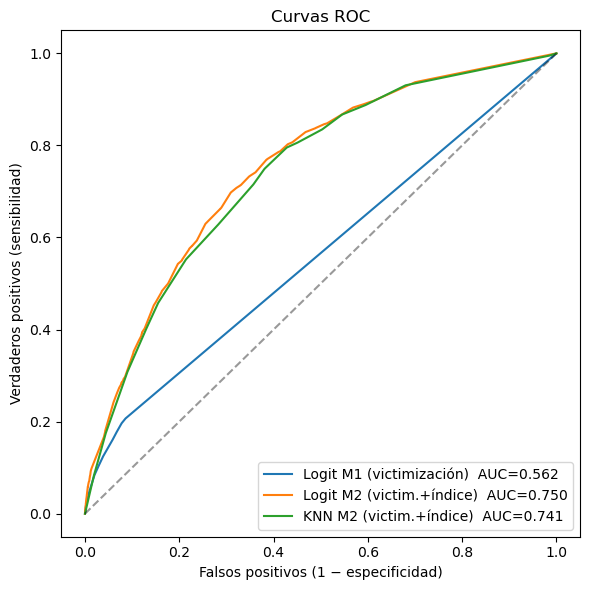


Logit M2 (victim.+índice)
  TN=11382 | FP=4637 (Tipo I) | FN=12745 (Tipo II) | TP=25294
  Sensibilidad=0.665 | Especificidad=0.711 | Precisión=0.845

KNN M2 (victim.+índice)
  TN=7960 | FP=8059 (Tipo I) | FN=6286 (Tipo II) | TP=31753
  Sensibilidad=0.835 | Especificidad=0.497 | Precisión=0.798


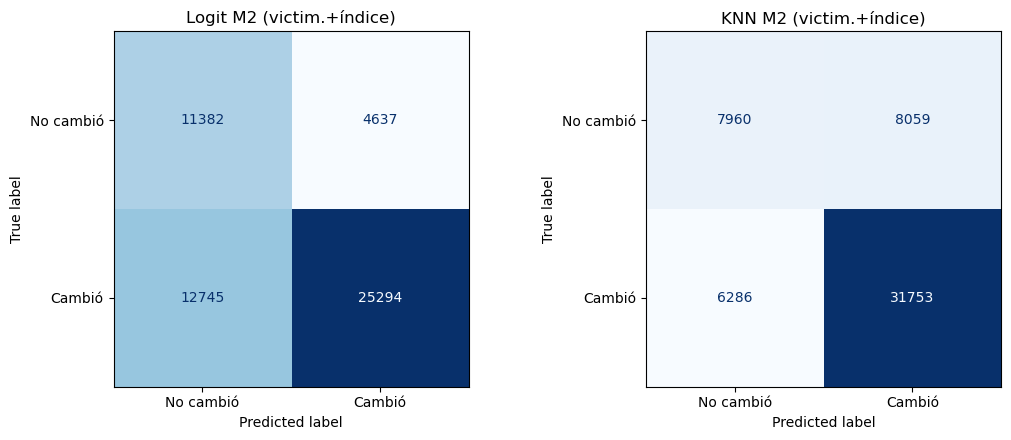

In [40]:
# Muestra común (mismas filas para M1 y M2)
b = base_pool_m2.dropna(subset=['Y_cambio_conducta']).reset_index(drop=True)
y = b['Y_cambio_conducta'].astype(int)
i_tr, i_te = train_test_split(np.arange(len(b)), test_size=0.3,
                              stratify=y, random_state=42)

def pipe(clf):
    return Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('sc', StandardScaler()), ('clf', clf)])

modelos = {
 'Logit M1 (victimización)':  (cols_X,  pipe(LogisticRegression(max_iter=1000, class_weight='balanced'))),
 'Logit M2 (victim.+índice)': (cols_m2, pipe(LogisticRegression(max_iter=1000, class_weight='balanced'))),
 'KNN M2 (victim.+índice)':   (cols_m2, pipe(KNeighborsClassifier(n_neighbors=25))),
}

# ---------- ROC ----------
plt.figure(figsize=(6,6)); fit = {}
for nombre,(cols,p) in modelos.items():
    p.fit(b.iloc[i_tr][cols], y.iloc[i_tr])
    proba = p.predict_proba(b.iloc[i_te][cols])[:,1]
    fpr,tpr,_ = roc_curve(y.iloc[i_te], proba)
    plt.plot(fpr, tpr, label=f"{nombre}  AUC={auc(fpr,tpr):.3f}")
    fit[nombre] = p
plt.plot([0,1],[0,1],'k--',alpha=.4)
plt.xlabel('Falsos positivos (1 − especificidad)')
plt.ylabel('Verdaderos positivos (sensibilidad)')
plt.title('Curvas ROC'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

# ---------- Matrices de confusión ----------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, nombre in zip(axes, ['Logit M2 (victim.+índice)','KNN M2 (victim.+índice)']):
    cols,_ = modelos[nombre]
    yhat = fit[nombre].predict(b.iloc[i_te][cols])
    cm = confusion_matrix(y.iloc[i_te], yhat)
    ConfusionMatrixDisplay(cm, display_labels=['No cambió','Cambió']).plot(
        cmap='Blues', ax=ax, colorbar=False); ax.set_title(nombre)
    tn,fp,fn,tp = cm.ravel()
    print(f"\n{nombre}\n  TN={tn} | FP={fp} (Tipo I) | FN={fn} (Tipo II) | TP={tp}")
    print(f"  Sensibilidad={tp/(tp+fn):.3f} | Especificidad={tn/(tn+fp):.3f} | Precisión={tp/(tp+fp):.3f}")
plt.tight_layout(); plt.show()